# 03 — Konstrukcija portfelja unaprijednim hodom

Benchmark portfelji novog dizajna (odluka 2026-06-12: bez grupnih capova —
vidi PROJECT_SPEC §3.5 i TASKS.md riješeno pitanje 8):

| # | Portfelj | Napomene |
|---|-----------|-------|
| 0 | Jednake težine | referenca 1/N |
| 1 | Minimalna varijanca | Ledoit-Wolf kovarijanca, `w_max=0.02` |

Grupno ograničene varijante (sektor / korelacijski klasteri / faktorski
klasteri, `group_cap=0.15`) uklonjene su iz panela. Izravna faktorska
neutralnost (notebook 05) ostaje kao benchmark mehanizma za H3.


In [1]:
%load_ext autoreload
%autoreload 2

import logging
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

if str(Path.cwd().parent) not in sys.path:
    sys.path.insert(0, str(Path.cwd().parent))

logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(message)s")

from src.backtest import PORTFOLIO_NAMES, generate_rolling_windows, run_walk_forward
from src.utils import (
    FIGURES_DIR,
    GROUP_CAP,
    PROCESSED_DATA_DIR,
    TABLES_DIR,
    W_MAX,
    ensure_dirs,
    set_seed,
)

ensure_dirs()
set_seed()


In [2]:
monthly_returns = pd.read_csv(
    PROCESSED_DATA_DIR / "monthly_returns.csv", index_col=0, parse_dates=True
)
factor_exposures = pd.read_csv(PROCESSED_DATA_DIR / "factor_exposures.csv")
factor_clusters = pd.read_csv(PROCESSED_DATA_DIR / "factor_clusters.csv")
correlation_clusters = pd.read_csv(PROCESSED_DATA_DIR / "correlation_clusters.csv")
metadata = pd.read_csv(PROCESSED_DATA_DIR / "metadata.csv")
windows = generate_rolling_windows()
print(f"{len(windows)} kliznih prozora; w_max={W_MAX}, group_cap={GROUP_CAP}")


21 kliznih prozora; w_max=0.02, group_cap=0.15


## 3.1 Pokreni unaprijedni backtest (Ledoit-Wolf primarni)


In [3]:
result = run_walk_forward(
    monthly_returns=monthly_returns,
    factor_exposures=factor_exposures,
    factor_clusters=factor_clusters,
    correlation_clusters=correlation_clusters,
    metadata=metadata,
    windows=windows,
    cov_estimator="ledoit_wolf",
    w_max=W_MAX,
    group_cap=GROUP_CAP,
    portfolios=("equal_weight", "min_var"),
)
weights_panel = result["weights_panel"]
port_returns_panel = result["port_returns_panel"]
portfolio_status = result["portfolio_status"]

weights_panel.to_csv(TABLES_DIR / "weights_panel.csv", index=False)
port_returns_panel.to_csv(TABLES_DIR / "port_returns_panel.csv", index_label="date")
portfolio_status.to_csv(TABLES_DIR / "portfolio_status.csv", index=False)

print("Sažetak statusa portfelja:")
print(portfolio_status.groupby(["portfolio", "status"]).size().unstack(fill_value=0))
print()
print("Mjeseci prinosa portfelja:", port_returns_panel.shape)


2026-06-12 09:33:35,409 WARNING Prozor 2013-12 izbacuje 2 oznaka dionica iz testnog univerzuma (nema testnih podataka).


2026-06-12 09:33:36,946 WARNING Prozor 2018-12 izbacuje 1 oznaka dionica iz testnog univerzuma (nema testnih podataka).


Sažetak statusa portfelja:
status        ok
portfolio       
equal_weight  21
min_var       21

Mjeseci prinosa portfelja: (252, 2)


## 3.2 Dijagnostika ograničenja


In [4]:
constraint_rows = []
for (window_label, portfolio_name), sub in weights_panel.groupby(
    ["train_window", "portfolio"]
):
    constraint_rows.append(
        {
            "train_window": window_label,
            "portfolio": portfolio_name,
            "max_w": sub["weight"].max(),
            "weight_sum": sub["weight"].sum(),
        }
    )
constraint_diag = pd.DataFrame(constraint_rows)
print("Najveća pojedinačna težina po portfelju (kroz sve prozore):")
print(constraint_diag.groupby("portfolio")["max_w"].max())
print("\nRaspon sume težina:",
      constraint_diag["weight_sum"].min(), "-", constraint_diag["weight_sum"].max())
violations = constraint_diag.loc[constraint_diag["max_w"] > W_MAX + 1e-9]
print(f"Prozora s kršenjem w_max: {len(violations)}")
assert violations.empty


Najveća pojedinačna težina po portfelju (kroz sve prozore):
portfolio
equal_weight    0.002237
min_var         0.020000
Name: max_w, dtype: float64

Raspon sume težina: 0.9999999999999996 - 1.0000000000000004
Prozora s kršenjem w_max: 0


## 3.3 Brzi pregled krivulje kapitala (kumulativno složeno)


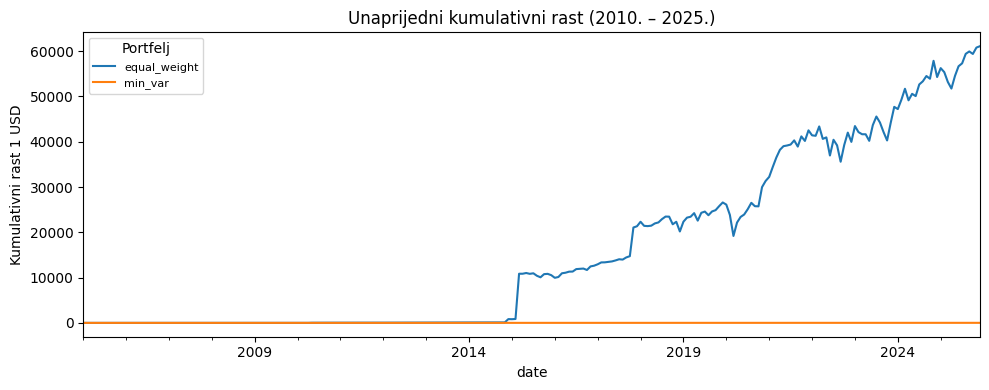

In [5]:
cumulative = (1.0 + port_returns_panel.fillna(0.0)).cumprod()
fig, ax = plt.subplots(figsize=(10, 4))
cumulative.plot(ax=ax)
ax.set_title("Unaprijedni kumulativni rast (2010. – 2025.)")
ax.set_ylabel("Kumulativni rast 1 USD")
ax.legend(title="Portfelj", fontsize=8, loc="upper left")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_cumulative_growth_preview.png", dpi=150)
plt.show()
